In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/00001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


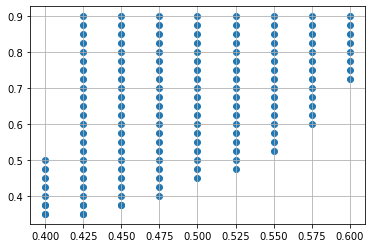

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [8]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [9]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [10]:
i_stepsize = 10
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  10 0.4000000000000001 0.40000000000000013
-------  20 0.4500000000000001 0.4500000000000002
-------  30 0.4250000000000001 0.5000000000000002
-------  40 0.5500000000000003 0.5250000000000002
-------  50 0.5000000000000002 0.5750000000000003
-------  60 0.4250000000000001 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  80 0.5750000000000002 0.6750000000000004
-------  90 0.47500000000000014 0.7250000000000004
-------  100 0.5250000000000001 0.7500000000000004
-------  110 0.5750000000000002 0.7750000000000005
-------  120 0.4250000000000001 0.8250000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  140 0.5250000000000001 0.8750000000000006
-------  150 0.5750000000000002 0.9000000000000006


In [11]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150]


In [12]:
factor_iteration = 10.

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]
    
##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1217.1004646667843
RUN  2 , total integrated cost =  145.54265181675115
RUN  3 , total integrated cost =  81.18076627177815
RUN  4 , total integrated cost =  57.89040775735947
RUN  5 , total integrated cost =  47.246167878868285
RUN  6 , total integrated cost =  37.964471287131595
RUN  7 , total integrated cost =  30.77362490051481
RUN  8 , total integrated cost =  21.662904899750878
RUN  9 , total integrated cost =  20.603745953979608
RUN  10 , total integrated cost =  19.57246499260319
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  47 , total integrated cost =  13.364006991165937
Improved over  47  iterations in  10.952863447368145  seconds by  99.77358375709682  percent.
Problem in initial value trasfer:  Vmean_exc -56.627620609847234 -56.62762055099662
weight =  4416.644261814645
set cost params:  1.0 0.0 4416.644261814645
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5873.038102885881
Gradient descend method:  None
RUN  1 , total integrated cost =  5069.690736000906
RUN  2 , total integrated cost =  5068.007241587993
RUN  3 , total integrated cost =  5066.974565799634
RUN  4 , total integrated cost =  5026.069066718552
RUN  5 , total integrated cost =  5024.404141392098
RUN  6 , total integrated cost =  5024.3685680614835
RUN  7 , total integrated cost =  5024.361606003612
RUN  8 , total integrated cost =  5024.359586832437
RUN  9 , total integrated cost =  5024.358710810786
RUN  10 , total integrated cost =  5024.358348125489
RUN  11 , total inte

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  5024.357915448925
Control only changes marginally.
RUN  22 , total integrated cost =  5024.3579154489125
Improved over  22  iterations in  0.4871041066944599  seconds by  14.45044579261193  percent.
Problem in initial value trasfer:  Vmean_exc -56.62596343265864 -56.62596386841035
-------  10 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.289828199723
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  1 , total integrated cost =  690.3960803722349
RUN  2 , total integrated cost =  106.07784409254252
RUN  3 , total integrated cost =  74.87618232783505
RUN  4 , total integrated cost =  60.90625076394285
RUN 

...

RUN  20 , total integrated cost =  31478.261892335926
Control only changes marginally.
RUN  26 , total integrated cost =  31478.261892334984
Improved over  26  iterations in  0.5620641857385635  seconds by  7.634666797490013  percent.
Problem in initial value trasfer:  Vmean_exc -56.70311918212211 -56.70311920300496
-------  90 0.47500000000000014 0.7250000000000004
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15143.755110304457
Gradient descend method:  None
RUN  0 , total integrated cost =  15143.755110304457
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15143.755110304457
Gradient descend method:  None
RUN  1 , total integrated cost =  15143.755110304457
Control only changes marginally.
RUN  1 , total integrated cost =  15143.755110304457
Improved over  1  iterations in  0.05147935263812542  seconds by  0.0 

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  333.0693701850853
RUN  6 , total integrated cost =  330.68729146790673
RUN  7 , total integrated cost =  330.68729146790673
Control only changes marginally.
RUN  7 , total integrated cost =  330.68729146790673
Improved over  7  iterations in  0.35670834220945835  seconds by  99.02426367513853  percent.
Problem in initial value trasfer:  Vmean_exc -56.703033912163264 -56.70305212325804
weight =  1024.86704094159
set cost params:  1.0 0.0 1024.86704094159
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28053.678672441936
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28053.678672441936
Control only changes marginally.
RUN  1 , total integrated cost =  28053.678672441936
Improved over  1  iterations in  0.09803168848156929  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703033912163264 -56.70305212325804
-------  120 0.4250000000000001 0.8250000000000005
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5845.286879790712
Gradient descend method:  None
RUN  0 , total integrated cost =  5845.286879790712
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5845.286879790712
Gradient descend method:  None
RUN  1 , total integrated cost =  5845.286879790712
Control only changes marginally.
RUN  1 , total integrated cost =  5845.286879790712
Improved over  1  iterations in  0.04041772149503231  seconds by  0.0  percent.
weight =  

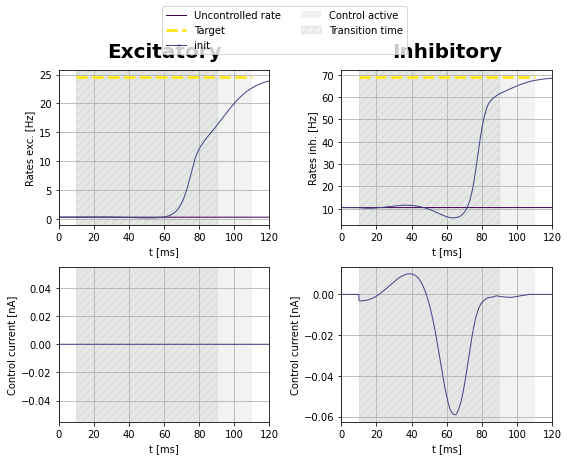

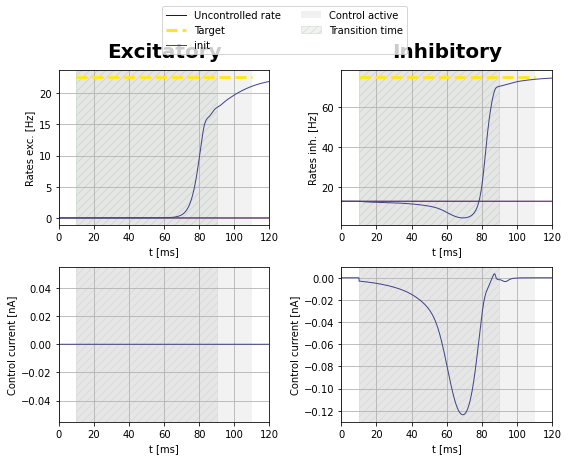

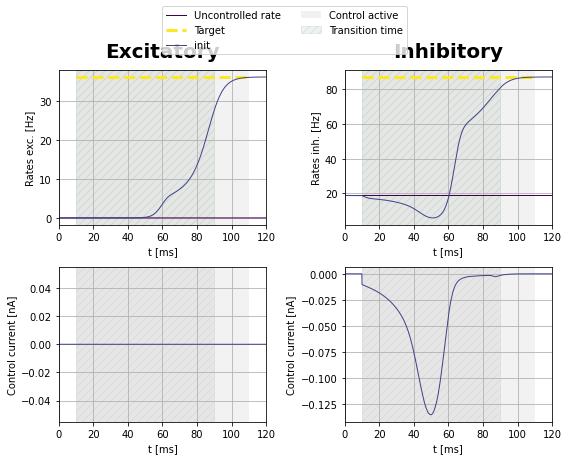

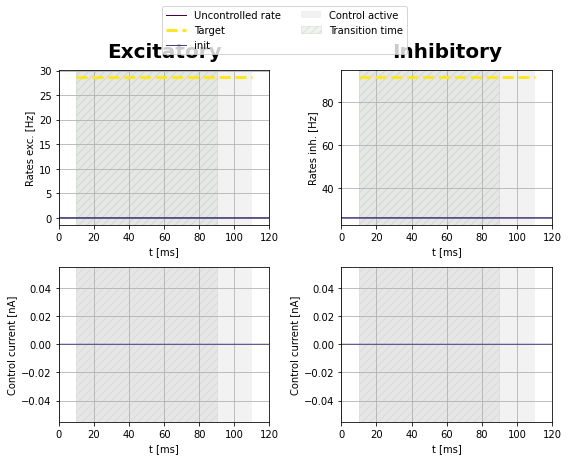

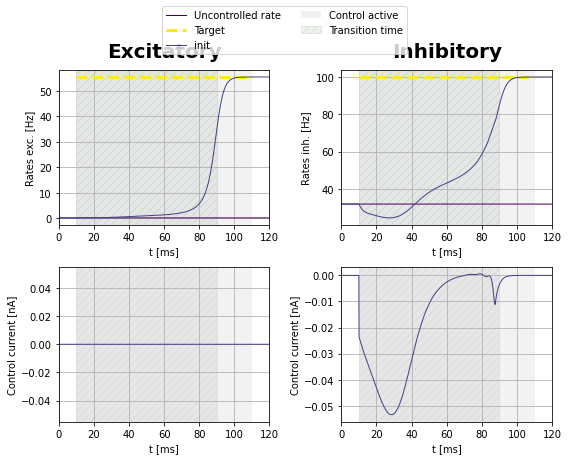

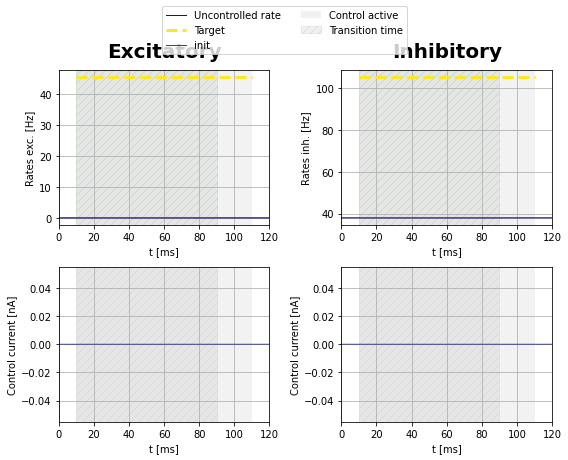

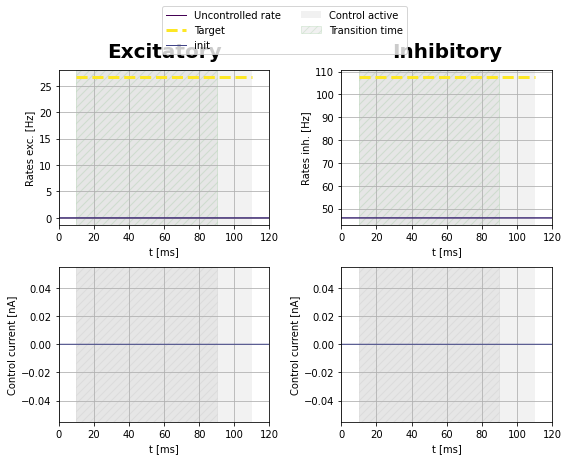

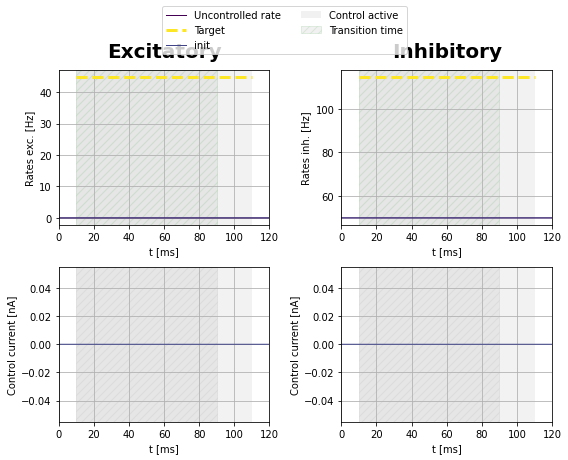

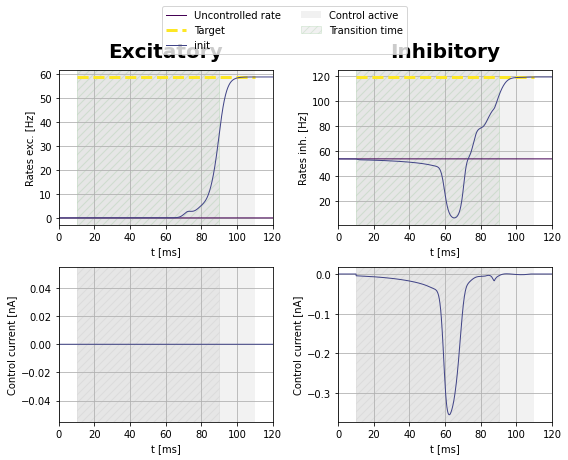

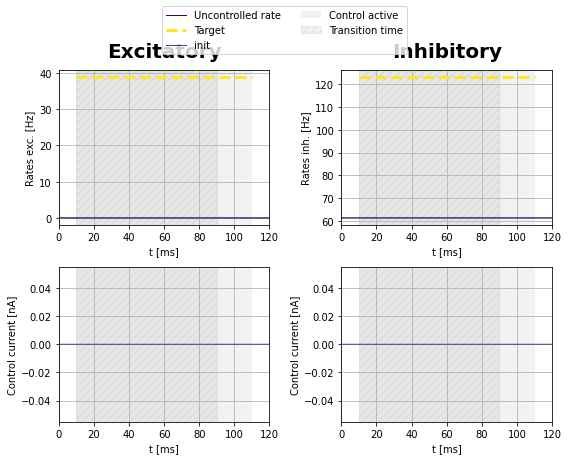

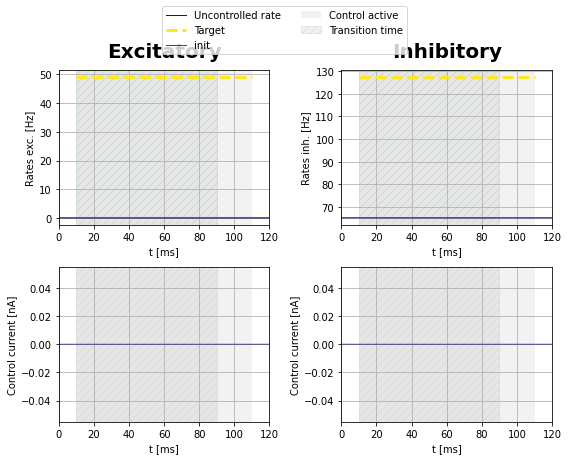

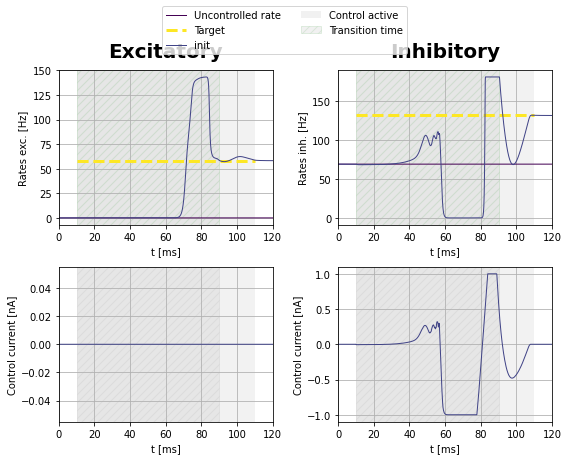

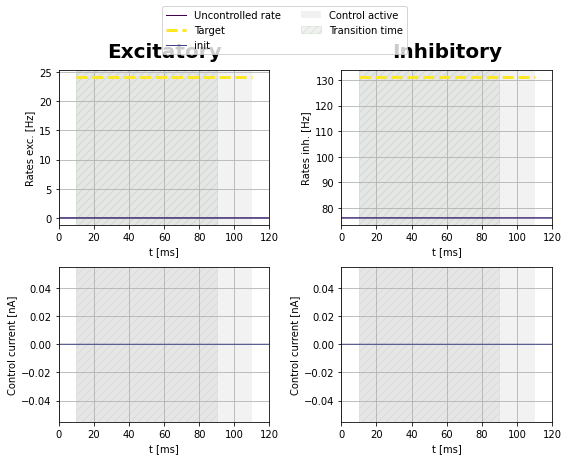

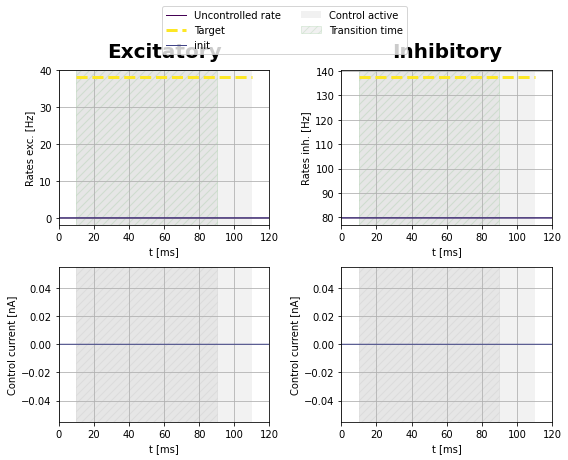

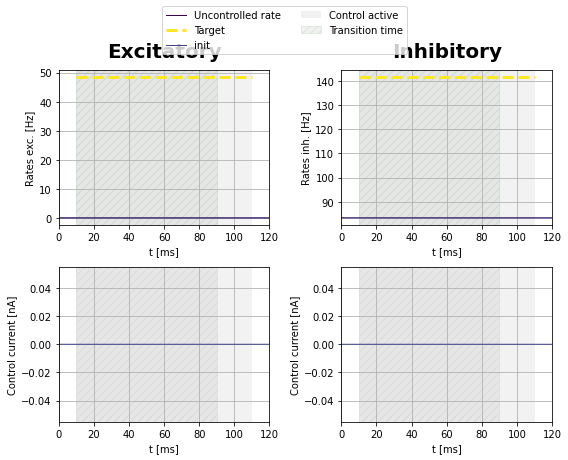

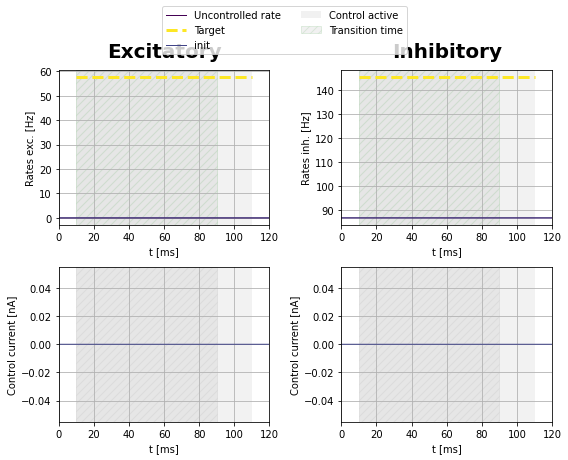

In [13]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [14]:
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
        continue
        
    print("no solution found for ", i)
    
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    if i != 0:
        control0 = bestControl_init[i-2*i_stepsize][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
-------  10 0.4000000000000001 0.40000000000000013
-------  20 0.4500000000000001 0.4500000000000002
-------  30 0.4250000000000001 0.5000000000000002
no solution found for  30
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8256.473085334586
Gradient descend method:  None
RUN  1 , total integrated cost =  8232.130252753615
RUN  2 , total integrated cost =  217.4805612816136
RUN  3 , total integrated cost =  164.69899226375395
RUN  4 , total integrated cost =  108.27844272368637
RUN  5 , total integrated cost =  87.7160024588157
RUN  6 , total integrated cost =  71.41732582940567
RUN  7 , total integrated cost =  69.93421874814156
RUN  8 , total integrated cost =  69.00856188393205
RUN  9 , total integrated cost =  68.088294207396
RUN  10 , total integrated cost =  67.31318217340507
RUN  11 , total integrated cost =  66.408077212984
RUN  12 , total integrated cost =  65.5233201072896

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  53.48026653098329
Control only changes marginally.
RUN  35 , total integrated cost =  53.48026653098322
Improved over  35  iterations in  0.7334191761910915  seconds by  99.35226257049179  percent.
Problem in initial value trasfer:  Vmean_exc -56.63969202721385 -56.63969440920063
weight =  1539.241996241561
set cost params:  1.0 0.0 1539.241996241561
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8220.866236881355
Gradient descend method:  None
RUN  1 , total integrated cost =  7999.8443281478885
RUN  2 , total integrated cost =  7969.925212619916


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  7969.925212619915
RUN  4 , total integrated cost =  7969.925212619915
Control only changes marginally.
RUN  4 , total integrated cost =  7969.925212619915
Improved over  4  iterations in  0.15883843973279  seconds by  3.0524888379236756  percent.
Problem in initial value trasfer:  Vmean_exc -56.63783880831361 -56.637865951897204
-------  40 0.5500000000000003 0.5250000000000002
-------  50 0.5000000000000002 0.5750000000000003
no solution found for  50
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2167.86723481337
Gradient descend method:  None
RUN  1 , total integrated cost =  57.14334204746662
RUN  2 , total integrated cost =  57.107418819681236
RUN  3 , total integrated cost =  56.7134619758265
RUN  4 , total integrated cost =  56.32590650483698
RUN  5 , total integrated cost =  56.3153477333838
RUN  6 , total integrated cost =  56.26338182104333
RUN  7 , total integrated cost =  56.1465905498

...

Control only changes marginally.
RUN  22 , total integrated cost =  14101.522414746796
Improved over  22  iterations in  0.47601742297410965  seconds by  2.753471806205468  percent.
Problem in initial value trasfer:  Vmean_exc -56.676945116192186 -56.67695367949533
-------  140 0.5250000000000001 0.8750000000000006
no solution found for  140
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  146.15131180178759
Gradient descend method:  None
RUN  1 , total integrated cost =  128.87841447729537
RUN  2 , total integrated cost =  128.67595313182278
RUN  3 , total integrated cost =  127.66421278717033
RUN  4 , total integrated cost =  126.86182813629179
RUN  5 , total integrated cost =  126.8199939960972
RUN  6 , total integrated cost =  124.9319452202775
RUN  7 , total integrated cost =  123.36230538276308
RUN  8 , total integrated cost =  123.343416740344
RUN  9 , total integrated cost =  122.91635356910673
RUN  10 , total integrated cos

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  22620.194049921294
Control only changes marginally.
RUN  32 , total integrated cost =  22620.19404992129
Improved over  32  iterations in  0.6903462130576372  seconds by  3.2467670482425035  percent.
Problem in initial value trasfer:  Vmean_exc -56.700659953715274 -56.70066055119091
-------  150 0.5750000000000002 0.9000000000000006
no solution found for  150
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  132.64559428110908
Gradient descend method:  None
RUN  1 , total integrated cost =  117.82519275527679
RUN  2 , total integrated cost =  105.8074751881072
RUN  3 , total integrated cost =  105.47857665231318
RUN  4 , total integrated cost =  105.34235672186422
RUN  5 , total integrated cost =  105.23486077215051
RUN  6 , total integrated cost =  104.98179712285399
RUN  7 , total integrated cost =  104.91912501915978
RUN  8 , total integrated cost =  104.84108498143037
RUN  9 , total integrated c

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  38 , total integrated cost =  31222.270903560202
Improved over  38  iterations in  0.8293025698512793  seconds by  5.238901689822285  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354405473704 -56.70354396515034


In [15]:
for k in range(10):

    factor_iteration = 10

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  5187.489782399709
set cost params:  1.0 0.0 5187.489782399709
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5855.6162417789765
Gradient descend method:  None
RUN  1 , total integrated cost =  5853.626174270826
RUN  2 , total integrated cost =  5853.571818061239
RUN  3 , total integrated cost =  5853.563660208321
RUN  4 , total integrated cost =  5853.5615104375665
RUN  5 , total integrated cost =  5853.560870870588
RUN  6 , total integrated cost =  5853.560656564933
RUN  7 , total integrated cost =  5853.560557048819
RUN  8 , total integrated cost =  5853.560515661002
RUN  9 , total integrated cost =  5853.5604988135965
RUN  10 , total integrated cost =  5853.560491156488
RUN  11 , total integrated cost =  5853.560488248273
RUN  12 , total integrated cost =  5853.560486909297
RUN  13 , total integrated cost =  5853.560486236649
RUN  14 , total integrated cost =  5853.5604859011055
RUN  15 , total integ

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  5853.560485563135
Control only changes marginally.
RUN  32 , total integrated cost =  5853.5604855631345
Improved over  32  iterations in  0.6998535450547934  seconds by  0.03510742731353389  percent.
Problem in initial value trasfer:  Vmean_exc -56.62602349904506 -56.62600093381703
-------  10 0.4000000000000001 0.40000000000000013
weight =  2026.6618762892883
set cost params:  1.0 0.0 2026.6618762892883
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5091.424407996941
Gradient descend method:  None
RUN  1 , total integrated cost =  5091.424407996941
Control only changes marginally.
RUN  1 , total integrated cost =  5091.424407996941
Improved over  1  iterations in  0.06716666556894779  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62659014344855 -56.62656380958566
-------  20 0.4500000000000001 0.4500000000000002
weight =  4939.573061485599
set cost params:  1.0 0.0 4939.573061485599
interpolate a

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  13010.09846774978
RUN  3 , total integrated cost =  13010.098467749774
RUN  4 , total integrated cost =  13010.098467749774
Control only changes marginally.
RUN  4 , total integrated cost =  13010.098467749774
Improved over  4  iterations in  0.16674074344336987  seconds by  0.0008326271503449334  percent.
Problem in initial value trasfer:  Vmean_exc -56.670288159146004 -56.67029729015339
-------  30 0.4250000000000001 0.5000000000000002
weight =  1588.8389214975698
set cost params:  1.0 0.0 1588.8389214975698
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8223.483028061093
Gradient descend method:  None
RUN  1 , total integrated cost =  8223.483028061093
Control only changes marginally.
RUN  1 , total integrated cost =  8223.483028061093
Improved over  1  iterations in  0.06893039122223854  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.63783880831361 -56.637865951897204
-------  40 0.55000000000000

...

RUN  1 , total integrated cost =  15133.825748745832
Control only changes marginally.
RUN  1 , total integrated cost =  15133.825748745832
Improved over  1  iterations in  0.0723023172467947  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.679718561292255 -56.679724594012924
-------  100 0.5250000000000001 0.7500000000000004
weight =  2787.353343761157
set cost params:  1.0 0.0 2787.353343761157
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24119.78920816434
Gradient descend method:  None
RUN  1 , total integrated cost =  24119.78920816434
Control only changes marginally.
RUN  1 , total integrated cost =  24119.78920816434
Improved over  1  iterations in  0.06713691540062428  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70139555977521 -56.701396007467665
-------  110 0.5750000000000002 0.7750000000000005
weight =  1237.5564337366347
set cost params:  1.0 0.0 1237.5564337366347
interpolate adjoint :  True

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5830.646111117192
Control only changes marginally.
RUN  1 , total integrated cost =  5830.646111117192
Improved over  1  iterations in  0.06576254218816757  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.623398904507624 -56.623405073979654
-------  130 0.47500000000000014 0.8500000000000005
weight =  1086.9498508304496
set cost params:  1.0 0.0 1086.9498508304496
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14534.607122739742
Gradient descend method:  None
RUN  1 , total integrated cost =  14534.607122739742
Control only changes marginally.
RUN  1 , total integrated cost =  14534.607122739742
Improved over  1  iterations in  0.06811769679188728  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67693706249886 -56.67694582067391
-------  140 0.5250000000000001 0.8750000000000006
weight =  2055.155279471737
set cost params:  1.0 0.0 2055.155279471737
interpolate adjoint :  Tr

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33280.398869644676
Control only changes marginally.
RUN  1 , total integrated cost =  33280.398869644676
Improved over  1  iterations in  0.07049725577235222  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354415305748 -56.7035440591871


In [16]:
with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [18]:
factor_iteration = 10
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  319.16442475079845
Gradient descend method:  None
RUN  1 , total integrated cost =  13.46219001281878
RUN  2 , total integrated cost =  13.381872165020559
RUN  3 , total integrated cost =  13.373593531844353
RUN  4 , total integrated cost =  13.354255720891993
RUN  5 , total integrated cost =  13.339112221729879
RUN  6 , total integrated cost =  13.331291196861907
RUN  7 , total integrated cost =  13.327112438638151
RUN  8 , total integrated cost =  13.31193968368826
RUN  9 , total integrated cost =  13.301215418133417
RUN  10 , total integrated cost =  13.298478089552702
RUN  11 , total integrated cost =  13.292482502136918
RUN  12 , total integrated cost =  13.28934779624163
RUN  13 , total integrated cost =  13.271197782132981
RUN  14 , total integrated cost =  13.259935995840321
RUN  15 , total integrated cost =  13.247960077450438


ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  65 , total integrated cost =  13.105429156403307
Improved over  65  iterations in  3.7571933064609766  seconds by  95.89383147365626  percent.
Problem in initial value trasfer:  Vmean_exc -56.627616003044785 -56.62761609890341
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  130.6087939457714
Gradient descend method:  HS
RUN  1 , total integrated cost =  129.087474208193
RUN  2 , total integrated cost =  128.0988596000323
RUN  3 , total integrated cost =  127.94207414017215
RUN  4 , total integrated cost =  127.92352026718977
RUN  5 , total integrated cost =  127.81212467614283
RUN  6 , total integrated cost =  126.6756995814083
RUN  7 , total integrated cost =  126.59035924295404
RUN  8 , total integrated cost =  126.53309121167621
RUN  9 , total integrated cost =  126.51408417550861
RUN  10 , total integrated cost =  126.40166953661421
RUN  11 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  45 , total integrated cost =  115.59877355410116
Improved over  45  iterations in  2.9562317449599504  seconds by  11.49235050581845  percent.
Problem in initial value trasfer:  Vmean_exc -56.62759358195955 -56.62759359786476
weight =  5104.942128768355
set cost params:  1.0 0.0 5104.942128768355
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5816.332035420402
Gradient descend method:  None
RUN  1 , total integrated cost =  5365.021234571675
RUN  2 , total integrated cost =  5352.092694755845
RUN  3 , total integrated cost =  5344.875063815384
RUN  4 , total integrated cost =  5326.020105524631
RUN  5 , total integrated cost =  5325.718006273061
RUN  6 , total integrated cost =  5325.597812628723
RUN  7 , total integrated cost =  5325.535128007826
RUN  8 , total integrated cost =  5325.502161532474
RUN  9 , total integrated cost =  5325.482531016304
RUN  10 , total integrated cost =  5325.4722000741895
RUN  11 , total integ

...

Control only changes marginally.
RUN  144 , total integrated cost =  1109.6663159871257
Improved over  144  iterations in  9.696537129580975  seconds by  2.4482824474956146  percent.
Problem in initial value trasfer:  Vmean_exc -56.70067754694779 -56.70067753018845
weight =  2119.6948254674253
set cost params:  1.0 0.0 2119.6948254674253
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23505.50914404732
Gradient descend method:  None
RUN  1 , total integrated cost =  23378.168278104993
RUN  2 , total integrated cost =  23364.819228559438
RUN  3 , total integrated cost =  23354.977295516914
RUN  4 , total integrated cost =  23349.844583085538
RUN  5 , total integrated cost =  23346.61215577366
RUN  6 , total integrated cost =  23344.764406854352
RUN  7 , total integrated cost =  23342.851426390243
RUN  8 , total integrated cost =  23341.287752892935
RUN  9 , total integrated cost =  23339.555546319218
RUN  10 , total integrated cost =  23337.80371577811
RUN  11 , 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  28 , total integrated cost =  23317.94183560834
Improved over  28  iterations in  2.291208438575268  seconds by  0.7979716894857347  percent.
Problem in initial value trasfer:  Vmean_exc -56.70068200680067 -56.70068150896674
-------  150 0.5750000000000002 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  433.7804785388271
Gradient descend method:  None
RUN  1 , total integrated cost =  99.70080501144577
RUN  2 , total integrated cost =  99.35967723096063
RUN  3 , total integrated cost =  99.12497854944243
RUN  4 , total integrated cost =  99.01174099654672
RUN  5 , total integrated cost =  98.87498151310439
RUN  6 , total integrated cost =  98.78424814914936
RUN  7 , total integrated cost =  98.6537993983359
RUN  8 , total integrated cost =  98.55536643230757
RUN  9 , total integrated cost =  98.48486142954677
RUN  10 , total integrated cost =  98.44780948031013
RUN  11 , tota

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  73 , total integrated cost =  860.8339879866704
Improved over  73  iterations in  4.689734300598502  seconds by  4.4850582417277565  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354405487751 -56.70354384238525
weight =  3866.186000025036
set cost params:  1.0 0.0 3866.186000025036
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33267.43915600225
Gradient descend method:  None
RUN  1 , total integrated cost =  32711.133437622262
RUN  2 , total integrated cost =  32631.807944908556
RUN  3 , total integrated cost =  32495.487571153713
RUN  4 , total integrated cost =  32419.113483100602
RUN  5 , total integrated cost =  32314.185758128267
RUN  6 , total integrated cost =  32232.805643520613
RUN  7 , total integrated cost =  32137.65640361881
RUN  8 , total integrated cost =  32052.465508117682
RUN  9 , total integrated cost =  31958.778522486366
RUN  10 , total integrated cost =  31871.142270223452
RUN  11 , tota

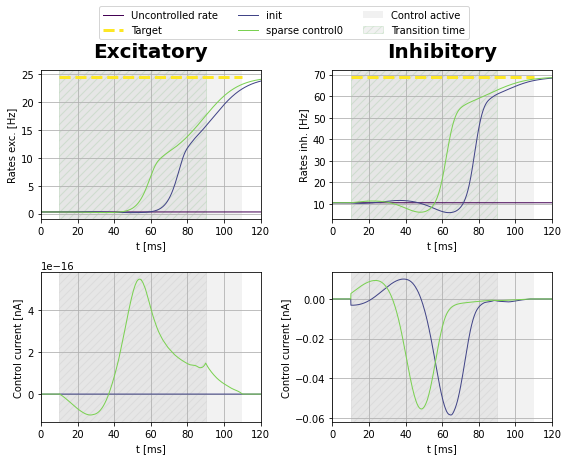

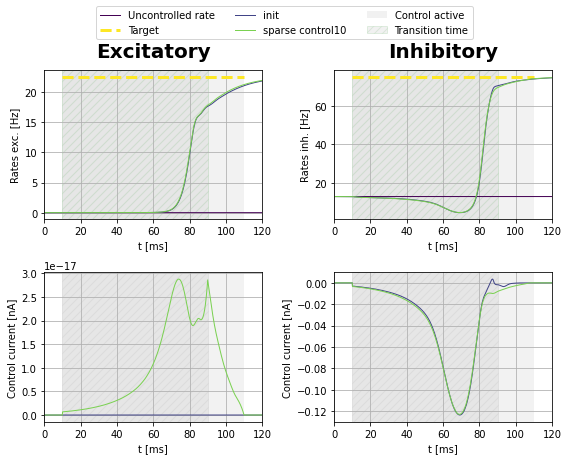

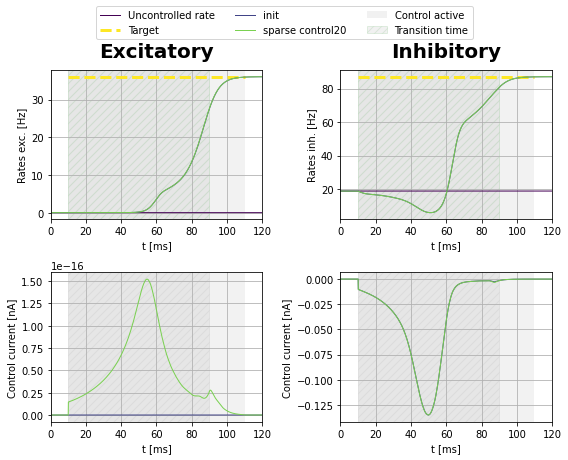

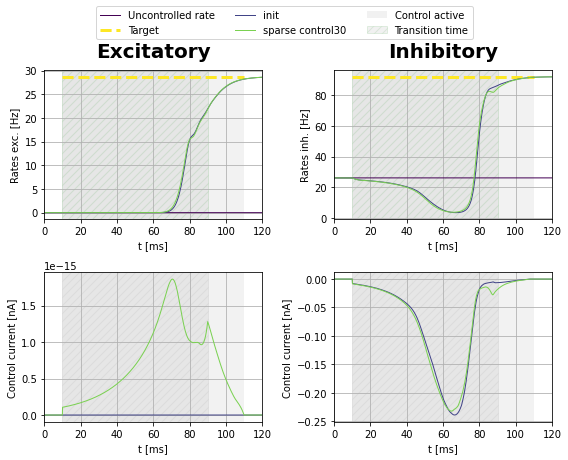

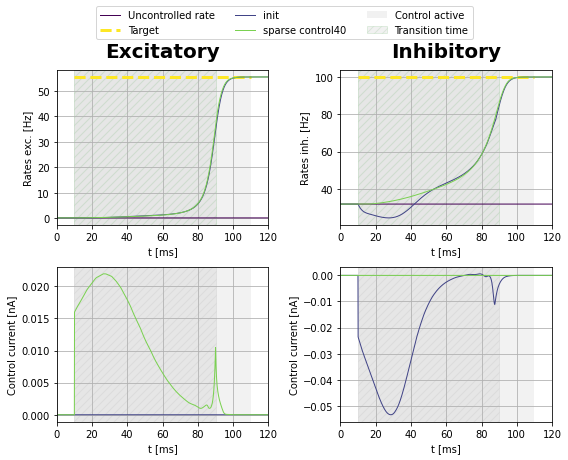

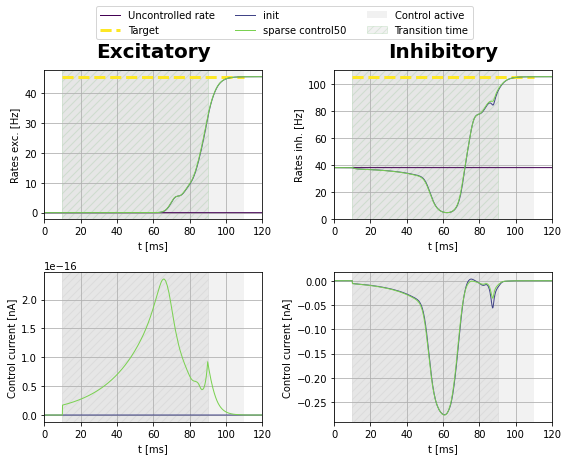

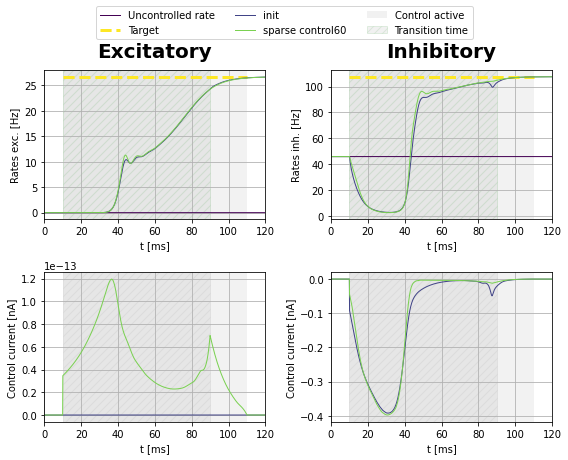

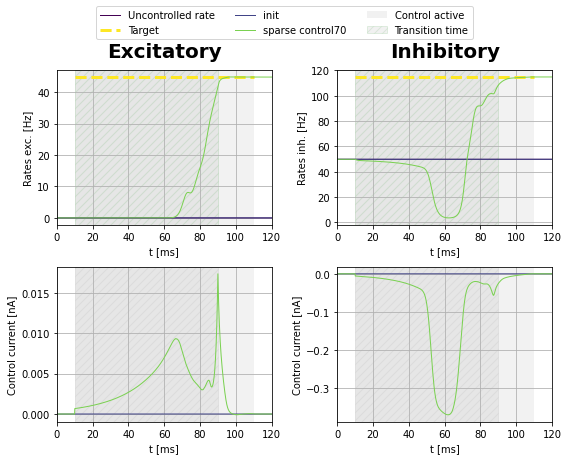

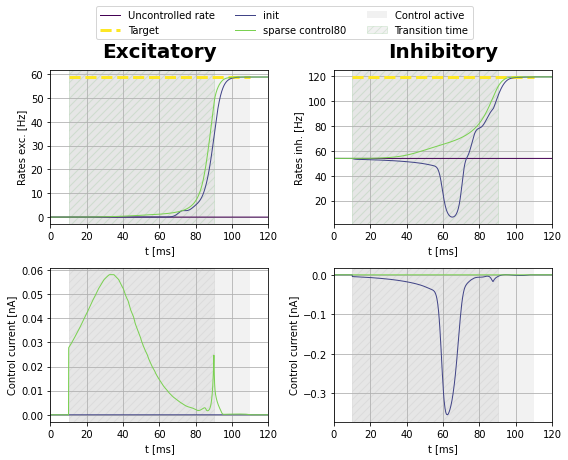

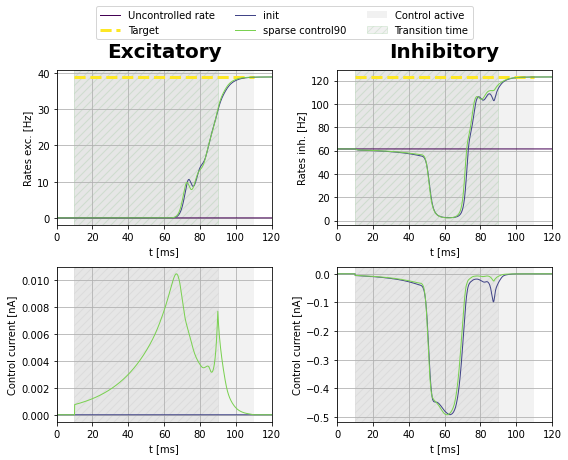

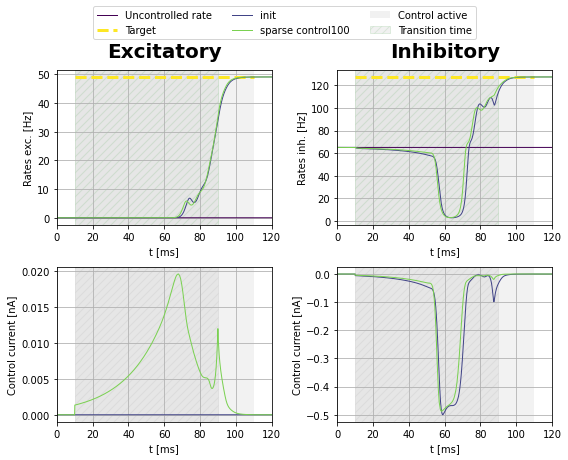

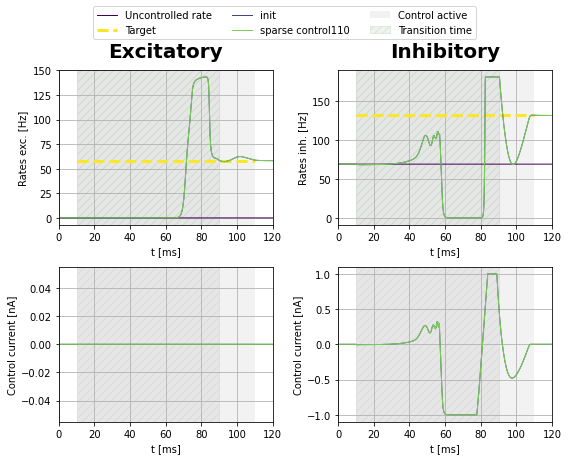

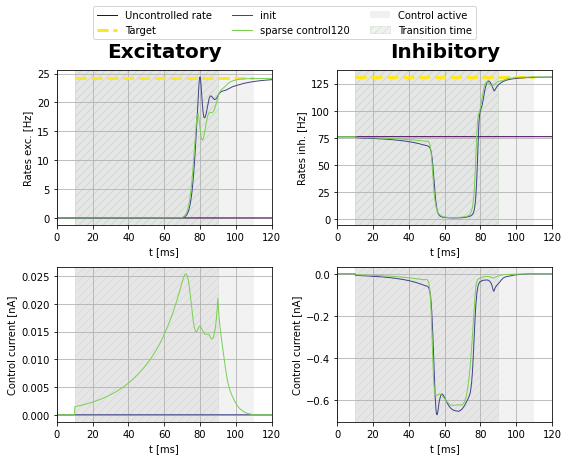

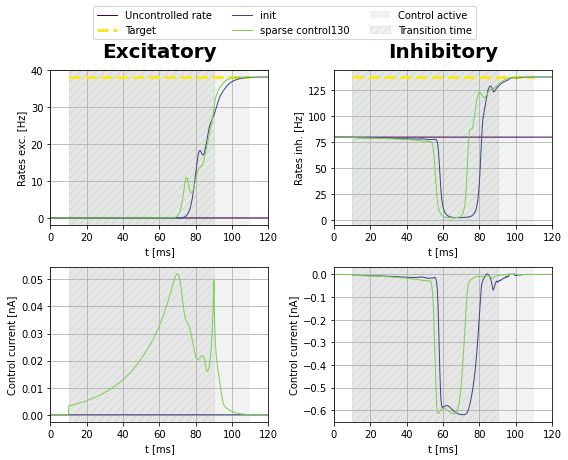

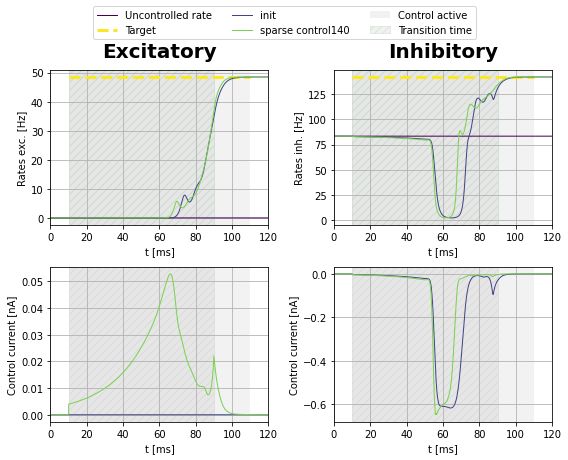

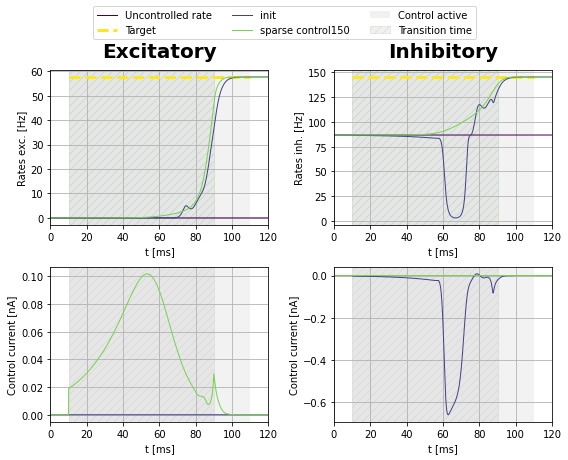

In [19]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [20]:
factor_iteration = 10

for k in range(10):
    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  5657.000561564565
set cost params:  1.0 0.0 5657.000561564565
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5883.643340883805
Gradient descend method:  None
RUN  1 , total integrated cost =  5883.624609339009
RUN  2 , total integrated cost =  5883.624282798133
RUN  3 , total integrated cost =  5883.624272010676
RUN  4 , total integrated cost =  5883.624271644749
RUN  5 , total integrated cost =  5883.624271630592
RUN  6 , total integrated cost =  5883.624271630195
RUN  7 , total integrated cost =  5883.6242716301895
RUN  8 , total integrated cost =  5883.624271630188
RUN  9 , total integrated cost =  5883.624271630182
RUN  10 , total integrated cost =  5883.62427163018
RUN  11 , total integrated cost =  5883.624271630179
State only changes marginally.


ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  5883.624271630179
Control only changes marginally.
RUN  12 , total integrated cost =  5883.624271630179
Improved over  12  iterations in  1.230338552966714  seconds by  0.0003241062131280614  percent.
Problem in initial value trasfer:  Vmean_exc -56.62600567986811 -56.62600725711751
-------  10 0.4000000000000001 0.40000000000000013
weight =  2029.3403004063673
set cost params:  1.0 0.0 2029.3403004063673
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5092.226626394167
Gradient descend method:  None
RUN  1 , total integrated cost =  5092.181822074602
RUN  2 , total integrated cost =  5092.181810945805
RUN  3 , total integrated cost =  5092.1818109397245
RUN  4 , total integrated cost =  5092.181810939709
RUN  5 , total integrated cost =  5092.181810939708


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5092.181810939708
Control only changes marginally.
RUN  6 , total integrated cost =  5092.181810939708
Improved over  6  iterations in  0.8223893269896507  seconds by  0.0008800758047016188  percent.
Problem in initial value trasfer:  Vmean_exc -56.626216915281894 -56.62619253038245
-------  20 0.4500000000000001 0.4500000000000002
weight =  4940.6751383372375
set cost params:  1.0 0.0 4940.6751383372375
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13012.126087695231
Gradient descend method:  None
RUN  1 , total integrated cost =  13012.100180366013


...

RUN  1 , total integrated cost =  33863.68724047168
Control only changes marginally.
RUN  1 , total integrated cost =  33863.68724047168
Improved over  1  iterations in  0.2847983166575432  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703033912163264 -56.70305212325804
-------  120 0.4250000000000001 0.8250000000000005
weight =  404.0847762743569
set cost params:  1.0 0.0 404.0847762743569
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5830.857093182706
Gradient descend method:  None
RUN  1 , total integrated cost =  5830.857093182706
Control only changes marginally.
RUN  1 , total integrated cost =  5830.857093182706
Improved over  1  iterations in  0.17623674124479294  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62413623010402 -56.62413578456345
-------  130 0.47500000000000014 0.8500000000000005
weight =  1130.961878922036
set cost params:  1.0 0.0 1130.961878922036
interpolate adjoint :  True True

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14535.12703896387
Control only changes marginally.
RUN  1 , total integrated cost =  14535.12703896387
Improved over  1  iterations in  0.18278048187494278  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67732886230356 -56.6773266644383
-------  140 0.5250000000000001 0.8750000000000006
weight =  2138.2803098716295
set cost params:  1.0 0.0 2138.2803098716295
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23521.63588471994
Gradient descend method:  None
RUN  1 , total integrated cost =  23521.63588471994
Control only changes marginally.
RUN  1 , total integrated cost =  23521.63588471994
Improved over  1  iterations in  0.18012136593461037  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700681946637985 -56.700681450897974
-------  150 0.5750000000000002 0.9000000000000006
weight =  12336.682059865114
set cost params:  1.0 0.0 12336.682059865114
interpolate adjoint :  True 

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33287.353224914164
Control only changes marginally.
RUN  1 , total integrated cost =  33287.353224914164
Improved over  1  iterations in  0.20167620852589607  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354289825369 -56.70354286089304


In [21]:
with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)